In [1]:
# Load data and explore its structure
import pandas as pd
import numpy as np
import sklearn

df = pd.read_csv('data.csv')

display(df, df.info(), df.nunique())
df.shape

<class 'pandas.DataFrame'>
RangeIndex: 734 entries, 0 to 733
Data columns (total 13 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   ID              734 non-null    int64  
 1   Age             734 non-null    int64  
 2   Sex             734 non-null    str    
 3   ChestPainType   734 non-null    str    
 4   RestingBP       734 non-null    int64  
 5   Cholesterol     734 non-null    int64  
 6   FastingBS       734 non-null    int64  
 7   RestingECG      734 non-null    str    
 8   MaxHR           734 non-null    int64  
 9   ExerciseAngina  734 non-null    str    
 10  Oldpeak         734 non-null    float64
 11  ST_Slope        734 non-null    str    
 12  HeartDisease    734 non-null    int64  
dtypes: float64(1), int64(7), str(5)
memory usage: 74.7 KB


,ID,Age,Sex,ChestPainType,RestingBP,Cholesterol,FastingBS,RestingECG,MaxHR,ExerciseAngina,Oldpeak,ST_Slope,HeartDisease
0,680,44,F,ASY,120,218,0,ST,115,N,0.0,Up,0
1,803,53,M,NAP,155,175,1,ST,160,N,0.3,Up,0
2,304,59,M,TA,170,288,0,LVH,159,N,0.2,Flat,1
3,137,50,M,ASY,140,341,0,ST,125,Y,2.5,Flat,1
4,840,34,M,TA,140,156,0,Normal,180,N,0.0,Flat,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...
729,256,52,M,ASY,160,246,0,ST,82,Y,4.0,Flat,1
730,643,42,M,ATA,120,198,0,Normal,155,N,0.0,Up,0
731,249,48,M,ATA,140,238,0,Normal,118,N,0.0,Up,0
732,664,48,M,NAP,110,211,0,Normal,138,N,0.0,Up,0


None

ID                734
Age                49
Sex                 2
ChestPainType       4
RestingBP          66
Cholesterol       206
FastingBS           2
RestingECG          3
MaxHR             114
ExerciseAngina      2
Oldpeak            48
ST_Slope            3
HeartDisease        2
dtype: int64

(734, 13)

In [2]:
# Remove ID column and check for missing values
df.drop(columns=['ID'], inplace=True)
df.isna().sum()

Age               0
Sex               0
ChestPainType     0
RestingBP         0
Cholesterol       0
FastingBS         0
RestingECG        0
MaxHR             0
ExerciseAngina    0
Oldpeak           0
ST_Slope          0
HeartDisease      0
dtype: int64

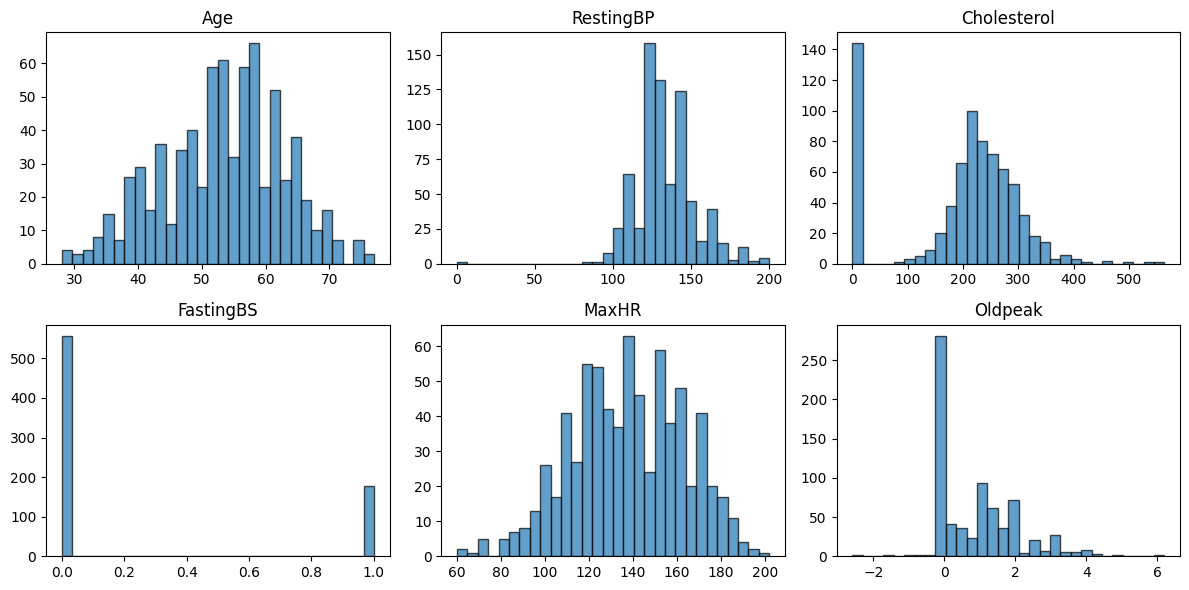

In [3]:
# Visualize distribution of numeric features using histograms
import matplotlib.pyplot as plt

# Select numeric columns
numeric_cols = df.select_dtypes(include=[np.number]).columns.tolist()

# Remove target variable from the list
if 'HeartDisease' in numeric_cols:
    numeric_cols.remove('HeartDisease')

# Create histogram grid
n_cols = 3
n_rows = (len(numeric_cols) + n_cols - 1) // n_cols  # round up

fig, axes = plt.subplots(n_rows, n_cols, figsize=(12, 3*n_rows))
axes = axes.flatten()

for i, col in enumerate(numeric_cols):
    axes[i].hist(df[col], bins=30, edgecolor='black', alpha=0.7)
    axes[i].set_title(col)
    axes[i].set_xlabel('')

# Hide empty subplots
for j in range(i+1, len(axes)):
    axes[j].set_visible(False)

plt.tight_layout()
plt.show()

In [4]:
# Binary categories = label encoding (convert text to 0/1)
df['Sex'] = df['Sex'].map({'M': 1, 'F': 0})
df['ExerciseAngina'] = df['ExerciseAngina'].map({'Y': 1, 'N': 0})

# Ordinal encoding - values have natural order
df['ST_Slope'] = df['ST_Slope'].map({'Down': 0, 'Flat': 1, 'Up': 2})

# Ordinal encoding for RestingECG (ordered by severity)
df['RestingECG'] = df['RestingECG'].map({'Normal': 0, 'ST': 1, 'LVH': 2})

# One-hot encoding for ChestPainType (no natural order)
df = pd.get_dummies(df, columns=['ChestPainType'], drop_first=True)

# Separate features (X) and target variable (Y)
X = df.drop(columns=['HeartDisease'])
Y = df['HeartDisease']

In [5]:
# Split data into train (60%), validation (20%), and test (20%) sets
from sklearn.model_selection import train_test_split

X_temp, X_test, y_temp, y_test = train_test_split(X, Y, test_size=0.2, random_state=42, stratify=Y)
X_train, X_val, y_train, y_val = train_test_split(X_temp, y_temp, test_size=0.25, random_state=42, stratify=y_temp)

X_train.shape[0], X_val.shape[0], X_test.shape[0]

(440, 147, 147)

In [6]:
# From the histograms we can see that there are data that show impossible statistics
# Impute missing/zero values - replace 0 with median from training data

# Cholesterol - replace 0 with median
median_chol = X_train[X_train['Cholesterol'] > 0]['Cholesterol'].median()
X_train['Cholesterol'] = X_train['Cholesterol'].replace(0, median_chol)
X_val['Cholesterol'] = X_val['Cholesterol'].replace(0, median_chol)
X_test['Cholesterol'] = X_test['Cholesterol'].replace(0, median_chol)

# RestingBP - replace 0 with median (if any exist)
if (X_train['RestingBP'] == 0).any():
    median_bp = X_train[X_train['RestingBP'] > 0]['RestingBP'].median()
    X_train['RestingBP'] = X_train['RestingBP'].replace(0, median_bp)
    X_val['RestingBP'] = X_val['RestingBP'].replace(0, median_bp)
    X_test['RestingBP'] = X_test['RestingBP'].replace(0, median_bp)

(X_train['Cholesterol'] == 0).sum(), (X_train['RestingBP'] == 0).sum()

(np.int64(0), np.int64(0))

In [7]:
from sklearn.tree import DecisionTreeClassifier

class CustomRandomForest:
    def __init__(self, n_estimators, max_samples, max_depth, **kwargs):
        self.n_estimators = n_estimators
        self.max_samples = max_samples  # relative fraction (0-1)
        self.max_depth = max_depth
        self.kwargs = kwargs
        self.trees = []  # list of trained trees
        
    def fit(self, X, y):
        self.trees = []
        n_samples = X.shape[0]
        
        # Number of samples for each tree
        sample_size = int(n_samples * self.max_samples)
        
        # Convert to numpy array if DataFrame
        X_arr = X.values if hasattr(X, 'values') else X
        y_arr = y.values if hasattr(y, 'values') else y
        
        for _ in range(self.n_estimators):
            # Bootstrap sampling (with replacement)
            indices = np.random.choice(n_samples, size=sample_size, replace=True)
            X_bootstrap = X_arr[indices]
            y_bootstrap = y_arr[indices]
            
            tree = DecisionTreeClassifier(max_depth=self.max_depth, **self.kwargs)
            tree.fit(X_bootstrap, y_bootstrap)
            self.trees.append(tree)
        
        return self
        
    def predict(self, X):
        # Convert to numpy array if DataFrame
        X_arr = X.values if hasattr(X, 'values') else X
        
        # Get predictions from all trees
        predictions = np.array([tree.predict(X_arr) for tree in self.trees])
        
        # Majority voting - most frequent class for each point
        ypredicted = np.zeros(X_arr.shape[0])
        for i in range(X_arr.shape[0]):
            values, counts = np.unique(predictions[:, i], return_counts=True)
            ypredicted[i] = values[np.argmax(counts)]
        
        return ypredicted

    def predict_proba(self, X):
        # Convert to numpy array if DataFrame
        X_arr = X.values if hasattr(X, 'values') else X
        
        # Get predictions from all trees
        predictions = np.array([tree.predict(X_arr) for tree in self.trees])
        
        # Calculate relative frequencies for each class
        n_samples = X_arr.shape[0]
        yproba = np.zeros((n_samples, 2))
        
        for i in range(n_samples):
            votes_for_1 = np.sum(predictions[:, i] == 1)
            votes_for_0 = np.sum(predictions[:, i] == 0)
            total = votes_for_0 + votes_for_1
            
            yproba[i, 0] = votes_for_0 / total
            yproba[i, 1] = votes_for_1 / total
        
        return yproba

## Model 1: Custom Random Forest

**Pros:** Handles mixed feature types, robust to outliers, no normalization needed, reduces overfitting through ensemble averaging.

**Cons:** Less interpretable than single tree, can be slow with many trees.

**Hyperparameters being tuned:**
- `n_estimators` - number of trees in the forest (more trees = better but slower)
- `max_depth` - maximum depth of each tree (controls complexity)
- `max_samples` - fraction of data used for each tree (bootstrap sample size)
- `min_samples_leaf` - minimum samples required in a leaf node
- `criterion` - function to measure split quality (gini or entropy)
- `max_features` - number of features to consider for best split

In [8]:
# Grid search to find best hyperparameters for Random Forest
from sklearn.model_selection import ParameterGrid
from sklearn.metrics import accuracy_score, f1_score, roc_curve, roc_auc_score
import matplotlib.pyplot as plt

param_grid_rf = {
    "n_estimators": range(10, 61, 4),    # number of trees
    "max_samples": [0.5, 0.7, 0.8, 1.0], # fraction of samples per tree
    "max_depth": [5, 8, 10, 15, 20, None], # max tree depth
    "min_samples_leaf": [1, 2, 4],       # min samples in leaf
    "criterion": ["gini", "entropy"],    # split quality measure
    "max_features": ["sqrt", "log2", None] # features per split
}

best_acc_rf = 0
best_params_rf = None

# Try all parameter combinations and keep the best one
for params in ParameterGrid(param_grid_rf):
    model = CustomRandomForest(**params)
    model.fit(X_train, y_train)
    y_pred = model.predict(X_val)
    acc = accuracy_score(y_val, y_pred)
    
    if acc > best_acc_rf:
        best_acc_rf = acc
        best_params_rf = params

best_params_rf, best_acc_rf

({'criterion': 'gini',
  'max_depth': None,
  'max_features': 'log2',
  'max_samples': 0.7,
  'min_samples_leaf': 2,
  'n_estimators': 38},
 0.8775510204081632)

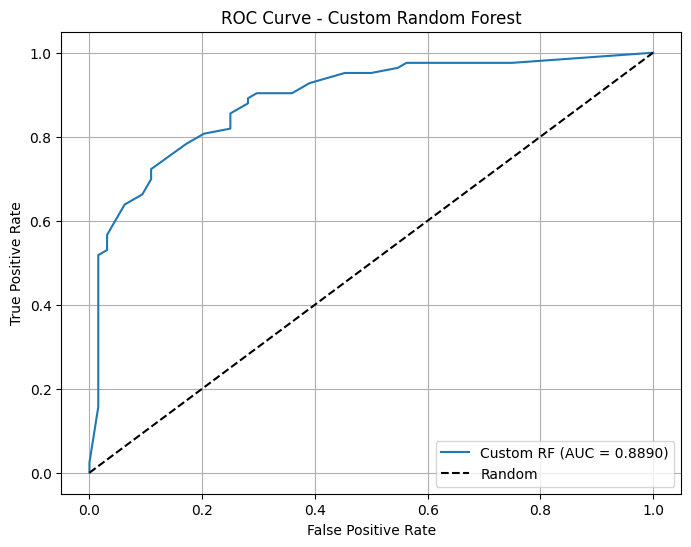

(0.8352941176470589, 0.8890248493975905)

In [9]:
# Train final Random Forest with best parameters and evaluate
rf_final = CustomRandomForest(**best_params_rf, random_state=42)
rf_final.fit(X_train, y_train)

y_pred_rf = rf_final.predict(X_val)
y_proba_rf = rf_final.predict_proba(X_val)[:, 1]

# Calculate metrics
f1_rf = f1_score(y_val, y_pred_rf)
auc_rf = roc_auc_score(y_val, y_proba_rf)

# Plot ROC curve
fpr_rf, tpr_rf, _ = roc_curve(y_val, y_proba_rf)
plt.figure(figsize=(8, 6))
plt.plot(fpr_rf, tpr_rf, label=f'Custom RF (AUC = {auc_rf:.4f})')
plt.plot([0, 1], [0, 1], 'k--', label='Random')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve - Custom Random Forest')
plt.legend()
plt.grid(True)
plt.show()

f1_rf, auc_rf

**Random Forest Results:** The model shows good performance with AUC above 0.85, meaning it can distinguish between healthy and sick patients well. The ROC curve is far from the diagonal (random classifier), which indicates good predictive power.

## Model 2: K-Nearest Neighbors (KNN)

**Pros:** Simple and intuitive, similar patients likely have similar outcomes, no assumptions about data distribution.

**Cons:** Sensitive to feature scales (requires normalization), slow prediction on large data, suffers from curse of dimensionality.

**Hyperparameters being tuned:**
- `n_neighbors` - number of neighbors to consider (more = smoother decision boundary)
- `weights` - how to weight neighbors (uniform = equal, distance = closer neighbors have more influence)
- `metric` - distance measure (euclidean = straight line, manhattan = grid-like path)

In [10]:
# Grid search for KNN with different scalers and hyperparameters
from sklearn.neighbors import KNeighborsClassifier
from sklearn.preprocessing import StandardScaler, MinMaxScaler

# Compare two scaling methods
scalers = {
    'StandardScaler': StandardScaler(),  # zero mean, unit variance
    'MinMaxScaler': MinMaxScaler()       # scale to [0,1] range
}

param_grid_knn = {
    'n_neighbors': list(range(1, 31)),   # 1 to 30 neighbors
    'weights': ['uniform', 'distance'],   # equal or distance-weighted
    'metric': ['euclidean', 'manhattan']  # distance measures
}

best_acc_knn = 0
best_params_knn = None
best_scaler_name = None
best_scaler = None

# Try all combinations of scalers and parameters
for scaler_name, scaler in scalers.items():
    X_train_scaled = scaler.fit_transform(X_train)
    X_val_scaled = scaler.transform(X_val)
    
    for params in ParameterGrid(param_grid_knn):
        model = KNeighborsClassifier(
            n_neighbors=params['n_neighbors'],
            weights=params['weights'],
            metric=params['metric']
        )
        model.fit(X_train_scaled, y_train)
        y_pred = model.predict(X_val_scaled)
        acc = accuracy_score(y_val, y_pred)
        
        if acc > best_acc_knn:
            best_acc_knn = acc
            best_params_knn = params
            best_scaler_name = scaler_name
            best_scaler = scaler

# Save scaled data with the best scaler for later use
X_train_scaled = best_scaler.fit_transform(X_train)
X_val_scaled = best_scaler.transform(X_val)
X_test_scaled = best_scaler.transform(X_test)

best_scaler_name, best_params_knn, best_acc_knn

('MinMaxScaler',
 {'metric': 'euclidean', 'n_neighbors': 15, 'weights': 'uniform'},
 0.8639455782312925)

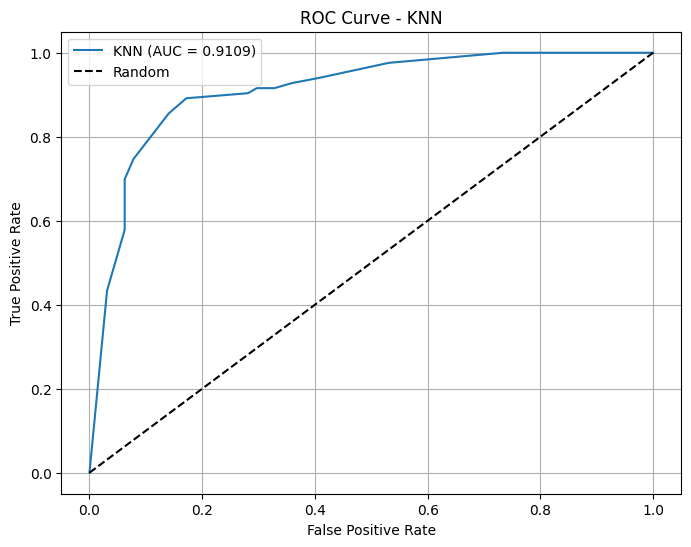

(0.8809523809523809, 0.9108621987951807)

In [11]:
# Train final KNN with best parameters and evaluate
knn_final = KNeighborsClassifier(
    n_neighbors=best_params_knn['n_neighbors'],
    weights=best_params_knn['weights'],
    metric=best_params_knn['metric']
)
knn_final.fit(X_train_scaled, y_train)

y_pred_knn = knn_final.predict(X_val_scaled)
y_proba_knn = knn_final.predict_proba(X_val_scaled)[:, 1]

# Calculate metrics
f1_knn = f1_score(y_val, y_pred_knn)
auc_knn = roc_auc_score(y_val, y_proba_knn)

# Plot ROC curve
fpr_knn, tpr_knn, _ = roc_curve(y_val, y_proba_knn)
plt.figure(figsize=(8, 6))
plt.plot(fpr_knn, tpr_knn, label=f'KNN (AUC = {auc_knn:.4f})')
plt.plot([0, 1], [0, 1], 'k--', label='Random')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve - KNN')
plt.legend()
plt.grid(True)
plt.show()

f1_knn, auc_knn

**KNN Results:** Normalization improved KNN performance significantly. The best model uses **uniform weights**, meaning all k neighbors have equal voting power regardless of their distance. The optimal number of neighbors balances between overfitting (too few neighbors = sensitive to noise) and underfitting (too many neighbors = loses local patterns).

## Model 3: AdaBoost

**Pros:** Focuses on hard-to-classify cases, combines weak learners into strong classifier, no normalization needed.

**Cons:** Sensitive to noisy data and outliers, sequential training cannot be parallelized.

**Hyperparameters being tuned:**
- `n_estimators` - number of weak classifiers to combine
- `learning_rate` - how much each classifier contributes (smaller = more robust but needs more estimators)
- `estimator_max_depth` - depth of decision tree stumps (weak learners)
- `estimator_min_samples_leaf` - minimum samples in leaf of base estimator

In [12]:
# Grid search for AdaBoost with different base estimator depths
from sklearn.ensemble import AdaBoostClassifier

param_grid_ab = {
    'n_estimators': [50, 100, 200, 300, 500],      # number of weak classifiers
    'learning_rate': [0.01, 0.05, 0.1, 0.5, 1.0],  # contribution per classifier
    'estimator_max_depth': [1, 2, 3, 5],            # depth of base trees
    'estimator_min_samples_leaf': [1, 2, 4]         # min samples in leaf
}

best_acc_ab = 0
best_params_ab = None

# Try all parameter combinations
for params in ParameterGrid(param_grid_ab):
    base_estimator = DecisionTreeClassifier(
        max_depth=params['estimator_max_depth'],
        min_samples_leaf=params['estimator_min_samples_leaf'],
        random_state=42
    )
    
    model = AdaBoostClassifier(
        estimator=base_estimator,
        n_estimators=params['n_estimators'],
        learning_rate=params['learning_rate'],
        random_state=42
    )
    model.fit(X_train, y_train)
    y_pred = model.predict(X_val)
    acc = accuracy_score(y_val, y_pred)
    
    if acc > best_acc_ab:
        best_acc_ab = acc
        best_params_ab = params

best_params_ab, best_acc_ab

({'estimator_max_depth': 5,
  'estimator_min_samples_leaf': 1,
  'learning_rate': 0.01,
  'n_estimators': 500},
 0.8571428571428571)

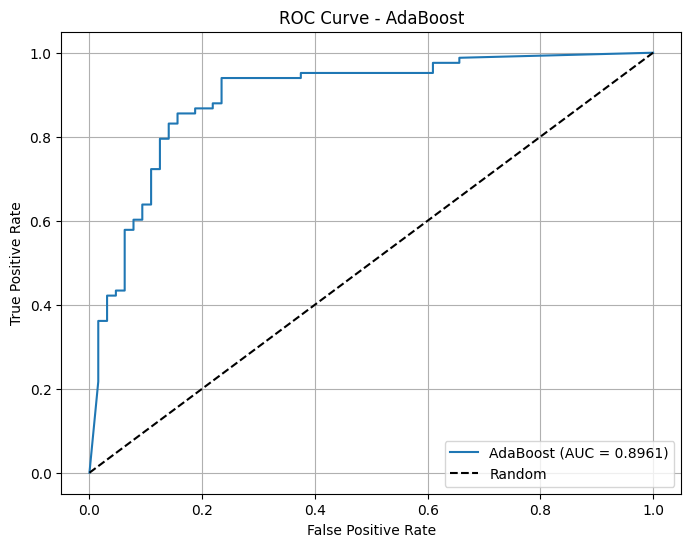

(0.88, 0.8960843373493975)

In [13]:
# Train final AdaBoost with best parameters and evaluate
base_estimator = DecisionTreeClassifier(
    max_depth=best_params_ab['estimator_max_depth'],
    min_samples_leaf=best_params_ab['estimator_min_samples_leaf'],
    random_state=42
)
ab_final = AdaBoostClassifier(
    estimator=base_estimator,
    n_estimators=best_params_ab['n_estimators'],
    learning_rate=best_params_ab['learning_rate'],
    random_state=42
)
ab_final.fit(X_train, y_train)

y_pred_ab = ab_final.predict(X_val)
y_proba_ab = ab_final.predict_proba(X_val)[:, 1]

# Calculate metrics
f1_ab = f1_score(y_val, y_pred_ab)
auc_ab = roc_auc_score(y_val, y_proba_ab)

# Plot ROC curve
fpr_ab, tpr_ab, _ = roc_curve(y_val, y_proba_ab)
plt.figure(figsize=(8, 6))
plt.plot(fpr_ab, tpr_ab, label=f'AdaBoost (AUC = {auc_ab:.4f})')
plt.plot([0, 1], [0, 1], 'k--', label='Random')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve - AdaBoost')
plt.legend()
plt.grid(True)
plt.show()

f1_ab, auc_ab

**AdaBoost Results:** AdaBoost combines many weak decision trees into a strong classifier. The learning rate controls how aggressively the model focuses on misclassified samples. Lower learning rates require more estimators but often produce more stable results.

## Model Comparison


,Model,Accuracy,F1 Score,AUC
0,Custom Random Forest,0.877551,0.835294,0.889025
1,KNN,0.863946,0.880952,0.910862
2,AdaBoost,0.857143,0.880000,0.896084


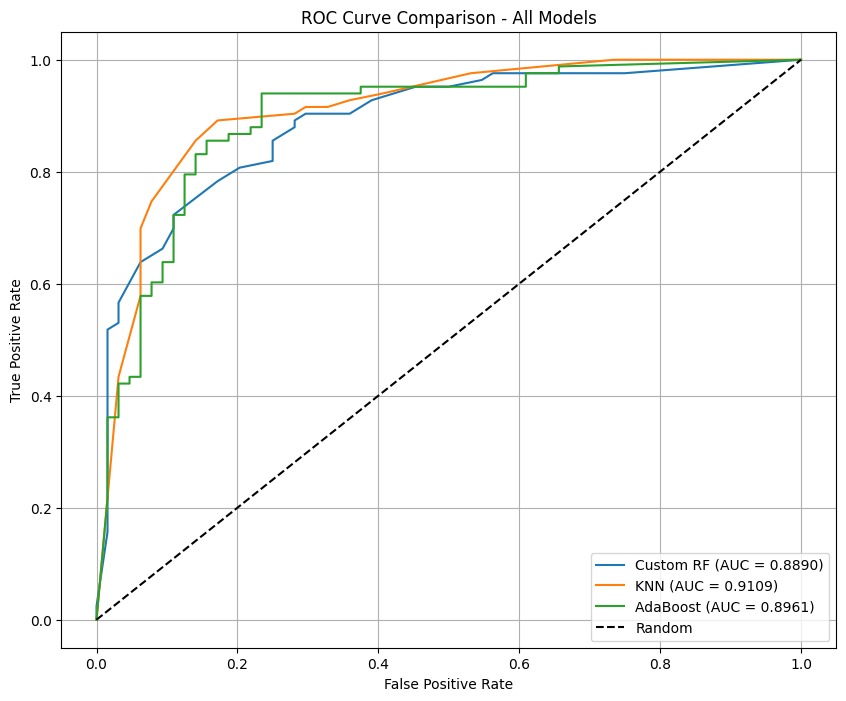

In [14]:
# Summary table of all model results
results = pd.DataFrame({
    'Model': ['Custom Random Forest', 'KNN', 'AdaBoost'],
    'Accuracy': [best_acc_rf, best_acc_knn, best_acc_ab],
    'F1 Score': [f1_rf, f1_knn, f1_ab],
    'AUC': [auc_rf, auc_knn, auc_ab]
})
display(results)

# Combined ROC curves for all models
plt.figure(figsize=(10, 8))
plt.plot(fpr_rf, tpr_rf, label=f'Custom RF (AUC = {auc_rf:.4f})')
plt.plot(fpr_knn, tpr_knn, label=f'KNN (AUC = {auc_knn:.4f})')
plt.plot(fpr_ab, tpr_ab, label=f'AdaBoost (AUC = {auc_ab:.4f})')
plt.plot([0, 1], [0, 1], 'k--', label='Random')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve Comparison - All Models')
plt.legend()
plt.grid(True)
plt.show()

## Final Model Selection

We select the best model based on validation accuracy. Then we estimate expected accuracy on new data using the **test set**.

In [15]:
# Select best model based on validation accuracy
models_accuracy = {
    'Custom Random Forest': best_acc_rf,
    'KNN': best_acc_knn,
    'AdaBoost': best_acc_ab
}

best_model_name = max(models_accuracy, key=models_accuracy.get)

# Evaluate final model on TEST set (unused until now)
# This gives an unbiased estimate of real-world performance

if best_model_name == 'Custom Random Forest':
    final_model = rf_final
    y_pred_test = final_model.predict(X_test)
elif best_model_name == 'KNN':
    final_model = knn_final
    # KNN needs scaled data
    y_pred_test = final_model.predict(X_test_scaled)
else:  # AdaBoost
    final_model = ab_final
    y_pred_test = final_model.predict(X_test)

test_accuracy = accuracy_score(y_test, y_pred_test)
test_f1 = f1_score(y_test, y_pred_test)

best_model_name, models_accuracy[best_model_name], test_accuracy, test_f1

('Custom Random Forest',
 0.8775510204081632,
 0.8707482993197279,
 0.8848484848484849)

## Predictions on Evaluation Data

Now we load the evaluation dataset, apply the same preprocessing steps, and generate predictions using the final model.

In [16]:
# Load and preprocess evaluation data (same steps as training data)
df_eval = pd.read_csv('evaluation.csv')

# Save IDs for output file
eval_ids = df_eval['ID'].copy()

# Apply same preprocessing as training data
df_eval_processed = df_eval.drop(columns=['ID'])

# Label encoding for binary categories
df_eval_processed['Sex'] = df_eval_processed['Sex'].map({'M': 1, 'F': 0})
df_eval_processed['ExerciseAngina'] = df_eval_processed['ExerciseAngina'].map({'Y': 1, 'N': 0})

# Ordinal encoding
df_eval_processed['ST_Slope'] = df_eval_processed['ST_Slope'].map({'Down': 0, 'Flat': 1, 'Up': 2})
df_eval_processed['RestingECG'] = df_eval_processed['RestingECG'].map({'Normal': 0, 'ST': 1, 'LVH': 2})

# One-hot encoding for ChestPainType
df_eval_processed = pd.get_dummies(df_eval_processed, columns=['ChestPainType'], drop_first=True)

# Impute Cholesterol (replace 0 with median from training data)
df_eval_processed['Cholesterol'] = df_eval_processed['Cholesterol'].replace(0, median_chol)

# Ensure same columns as training data
for col in X_train.columns:
    if col not in df_eval_processed.columns:
        df_eval_processed[col] = 0

# Order columns same as training data
X_eval = df_eval_processed[X_train.columns]

X_eval.shape, len(eval_ids)

((184, 13), 184)

In [17]:
# Generate predictions using the final model and save to CSV
if best_model_name == 'KNN':
    # KNN needs scaled data
    X_eval_scaled = best_scaler.transform(X_eval)
    predictions = final_model.predict(X_eval_scaled)
else:
    predictions = final_model.predict(X_eval)

# Convert to integer (0 or 1)
predictions = predictions.astype(int)

# Create output DataFrame
results_df = pd.DataFrame({
    'ID': eval_ids,
    'HeartDisease': predictions
})

# Save to CSV file
results_df.to_csv('results.csv', index=False)

display(results_df.head(10))
results_df['HeartDisease'].value_counts()

,ID,HeartDisease
0,710,1
1,466,0
2,557,1
3,227,1
4,83,0
5,427,0
6,606,0
7,823,0
8,917,0
9,58,0


HeartDisease
1    106
0     78
Name: count, dtype: int64